In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import warnings 
warnings.filterwarnings('ignore') 



In [39]:
df = pd.read_csv("../data/raw/new_data_test.csv", sep='\t')
display(df.head())

,Unnamed: 0,reviewID,reviewerID,restaurantID,date,rating,reviewUsefulCount,reviewContent,flagged,name,...,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength
0,7267,dLS_UUea0Yh7et2YlGpUOw,hfQu0YNy_XW5oiiripgUFg,8d_DiHWB-pjBVW3a7D8EWg,1/25/2012,4,0,sunda amazing i heard many good things finally...,1,Mallory M.,...,1,0,0,0,0,0,0,0,4.0,72
1,731,EDejgdY32F8Lr4ewh7FeiA,_jsZl-USMgrVVasNg50wAQ,boE4Ahsssqic7o5wQLI04w,5/5/2012,4,0,absolutely fantastic foodie community table gr...,0,Shawn K.,...,1,0,0,0,0,0,5,0,4.0,12
2,9902,TRLtyGBT7VFODhxgyZ2tLA,sZxXpvmBUN2fSCtK_BZFoQ,ms5ge1XY9-Alu7HkybAMdQ,11/9/2007,3,0,i work right rarely go here they 5 personal st...,0,Dane K.,...,845,143,2499,1451,1151,1377,2,55,3.5,102
3,25894,6QYZT3mkrmBmYNDUN18ILg,YMS9Fzy0OcOXFcS_qms_pg,3Mx2PM7v8qjqhgF3cDXxbQ,6/20/2011,3,0,this best big 3 brazilian steakhouses chicago ...,1,Pennywise S.,...,2,0,0,0,0,0,0,0,4.0,30
4,17519,xuKTaBhJT0GaI4wRFZi6Qw,uvWWKett-BIRbvyLZXaloQ,vvhfPV-Llkd4fE2SHuLVvA,9/28/2009,4,0,i lunch the gage group 8 this first time there...,1,Rich C.,...,1,0,0,0,0,0,0,0,4.0,93


#
## 1) EXPLORATORY DATA ANALYSIS
#

In [40]:
display(df.info())

print("\n\n")
display(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2483 non-null   int64  
 1   reviewID           2483 non-null   object 
 2   reviewerID         2483 non-null   object 
 3   restaurantID       2483 non-null   object 
 4   date               2483 non-null   object 
 5   rating             2483 non-null   int64  
 6   reviewUsefulCount  2483 non-null   int64  
 7   reviewContent      2483 non-null   object 
 8   flagged            2483 non-null   int64  
 9   name               2483 non-null   object 
 10  location           2481 non-null   object 
 11  yelpJoinDate       2483 non-null   object 
 12  friendCount        2483 non-null   int64  
 13  reviewCount        2483 non-null   int64  
 14  firstCount         2483 non-null   int64  
 15  usefulCount        2483 non-null   int64  
 16  coolCount          2483 

None

(2483, 23)

In [41]:
# datatypes are impproper so we will fix that 

df['date'] = pd.to_datetime(df['date'],errors = 'coerce')
df['yelpJoinDate'] = pd.to_datetime(df['yelpJoinDate'],format='%B %Y', errors='coerce')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         2483 non-null   int64         
 1   reviewID           2483 non-null   object        
 2   reviewerID         2483 non-null   object        
 3   restaurantID       2483 non-null   object        
 4   date               2483 non-null   datetime64[ns]
 5   rating             2483 non-null   int64         
 6   reviewUsefulCount  2483 non-null   int64         
 7   reviewContent      2483 non-null   object        
 8   flagged            2483 non-null   int64         
 9   name               2483 non-null   object        
 10  location           2481 non-null   object        
 11  yelpJoinDate       2483 non-null   datetime64[ns]
 12  friendCount        2483 non-null   int64         
 13  reviewCount        2483 non-null   int64         
 14  firstCou

In [42]:
df.isnull().sum()
## location has two null values so remove those rows

Unnamed: 0           0
reviewID             0
reviewerID           0
restaurantID         0
date                 0
rating               0
reviewUsefulCount    0
reviewContent        0
flagged              0
name                 0
location             2
yelpJoinDate         0
friendCount          0
reviewCount          0
firstCount           0
usefulCount          0
coolCount            0
funnyCount           0
complimentCount      0
tipCount             0
fanCount             0
restaurantRating     0
ReviewLength         0
dtype: int64

In [43]:
missing_locations = df[df['location'].isna()]
display(missing_locations[['location']]) 

df.dropna(subset = ['location'] , inplace = True)


,location
723,NaN
1199,NaN


In [44]:
missing_locations = df[df['location'].isna()]
display(missing_locations)
df.isnull().sum()

,Unnamed: 0,reviewID,reviewerID,restaurantID,date,rating,reviewUsefulCount,reviewContent,flagged,name,...,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength


Unnamed: 0           0
reviewID             0
reviewerID           0
restaurantID         0
date                 0
rating               0
reviewUsefulCount    0
reviewContent        0
flagged              0
name                 0
location             0
yelpJoinDate         0
friendCount          0
reviewCount          0
firstCount           0
usefulCount          0
coolCount            0
funnyCount           0
complimentCount      0
tipCount             0
fanCount             0
restaurantRating     0
ReviewLength         0
dtype: int64

#
## Target Variable Distribution
#

flagged
1    51.14873
0    48.85127
Name: proportion, dtype: float64

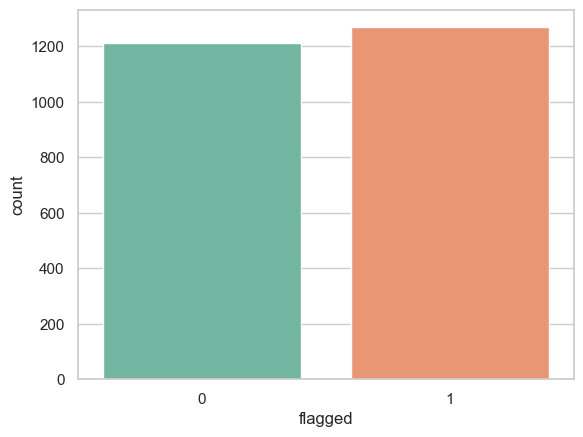

In [67]:
sns.set_theme(style="whitegrid")
sns.countplot(data=df,x='flagged',palette='Set2')
plt.savefig("../images-recordings/figures/target_variable_distribution.png")
# balanced rows flagged as 0 and 1

display(df['flagged'].value_counts(normalize=True)*100)

#
## Categorical variables Distribution w.r.t Target Variable
#

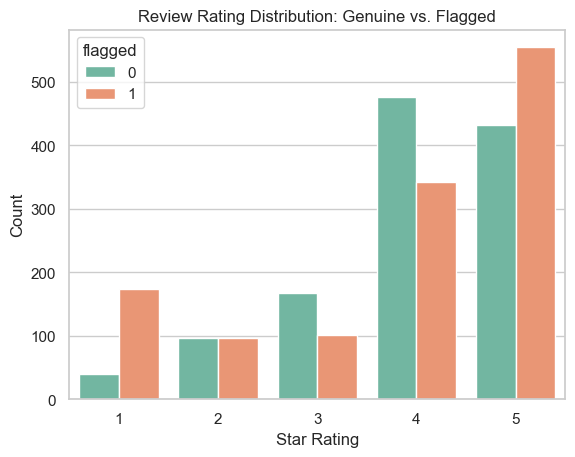

In [68]:
sns.countplot(data=df, x='rating', hue='flagged', palette='Set2')
plt.title('Review Rating Distribution: Genuine vs. Flagged')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.savefig("../images-recordings/figures/review_rating_distribution.png")
plt.show()

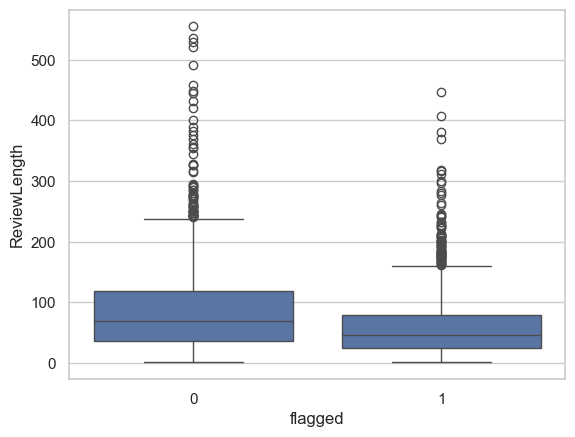

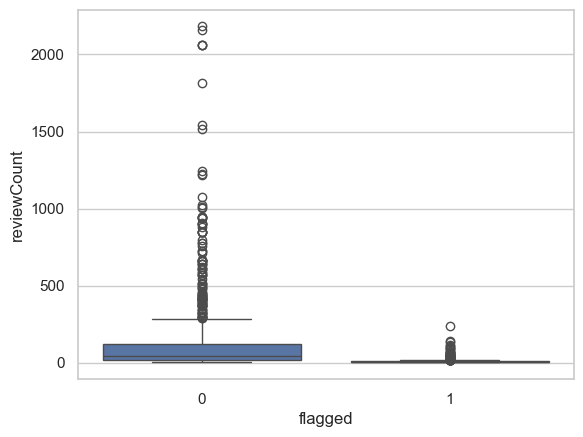

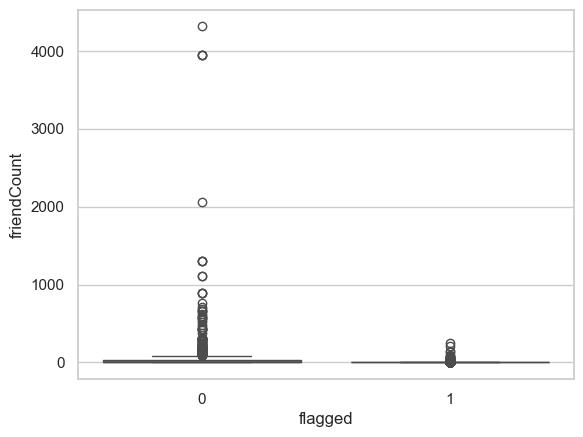

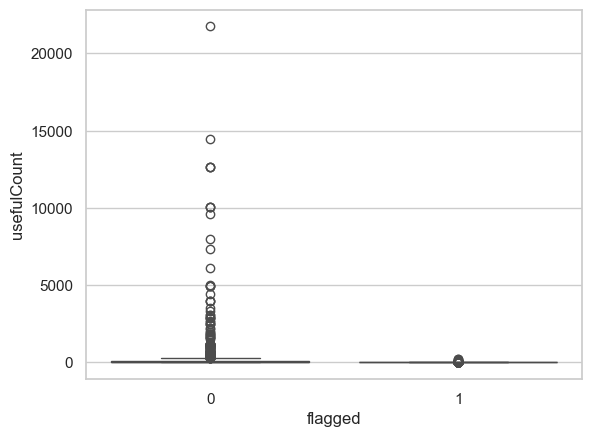

In [54]:
quant_cols = ['ReviewLength', 'reviewCount', 'friendCount', 'usefulCount']
for col in quant_cols:
    sns.boxplot(data=df, x='flagged', y=col)
    plt.show()

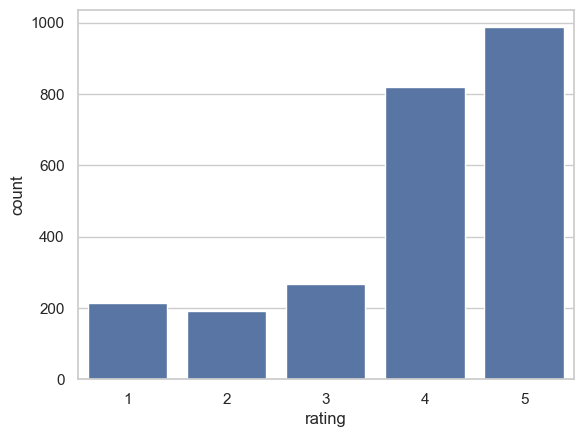

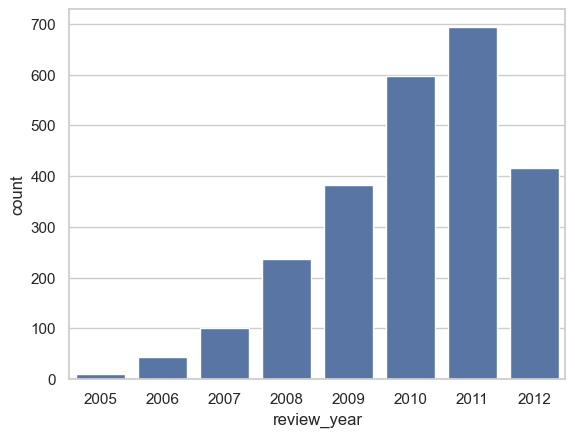

In [55]:
# year column for a temporal category 
df['review_year'] = df['date'].dt.year

# List of categorical columns
cat_cols = ['rating', 'review_year']


for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.show()

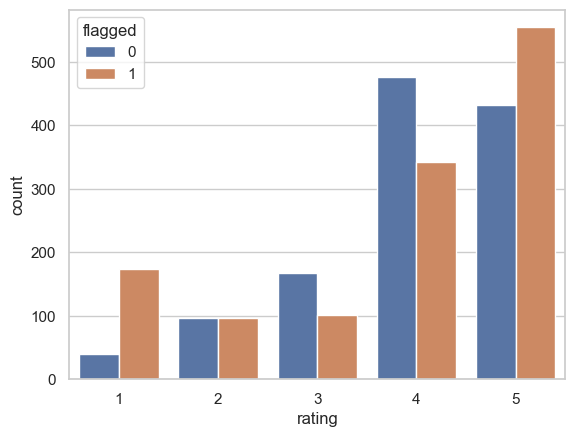

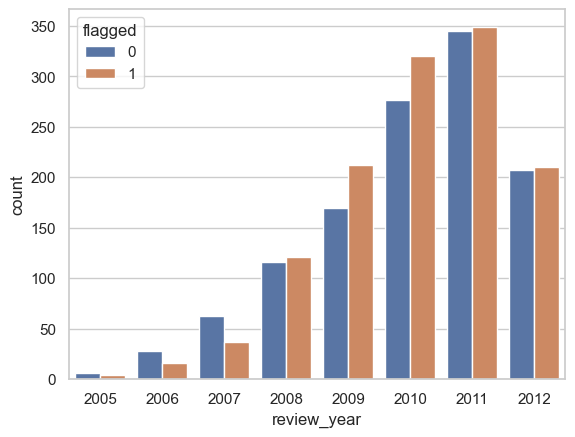

In [56]:
for col in cat_cols:
    sns.countplot(data=df, x=col, hue='flagged')
    plt.show()

## Correlation

In [57]:
numeric_cols = [
    'flagged', 'rating', 'ReviewLength', 'reviewCount', 'friendCount', 
    'usefulCount', 'reviewUsefulCount', 'coolCount', 'funnyCount', 
    'complimentCount', 'tipCount', 'fanCount', 'firstCount', 'restaurantRating'
]

# Create a new DataFrame with just these columns
df_numeric = df[numeric_cols]


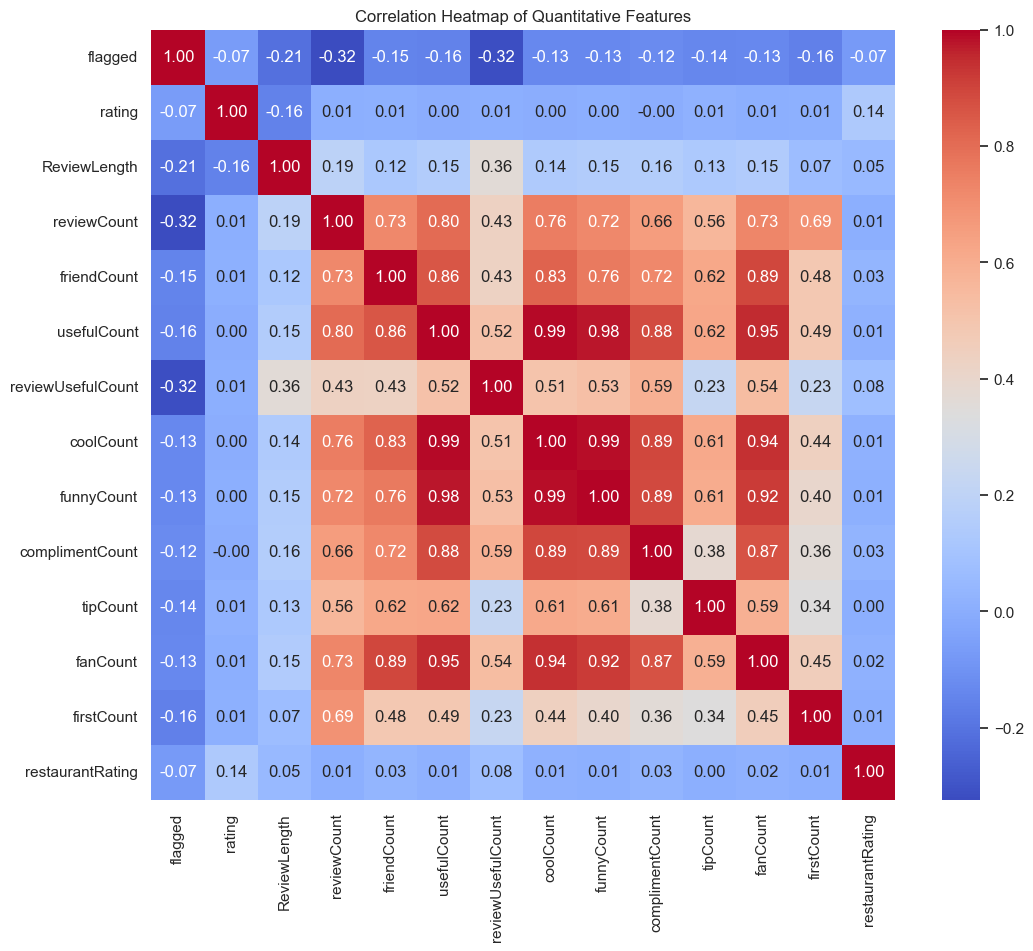

In [69]:
corr_matrix = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Quantitative Features")
plt.savefig("../images-recordings/figures/eda_correlation_numeric_features.png")
plt.show()

## Text Length Analysis

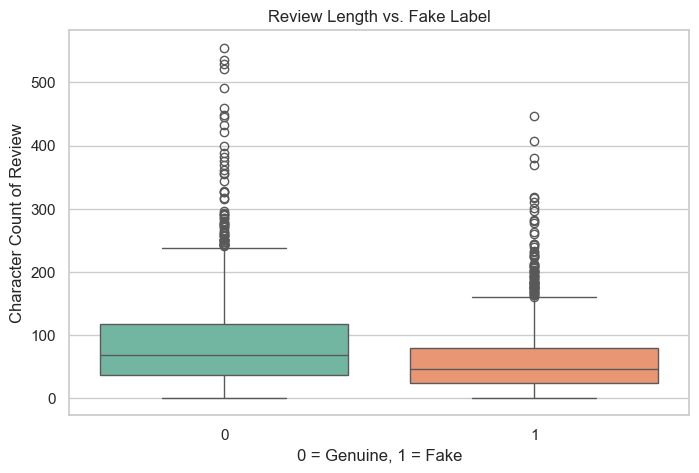

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Simple boxplot for ReviewLength vs Flagged
sns.boxplot(data=df, x='flagged', y='ReviewLength', palette='Set2')

plt.title('Review Length vs. Fake Label')
plt.xlabel('0 = Genuine, 1 = Fake')
plt.ylabel('Character Count of Review')
plt.show()

In [62]:
df.to_csv('../data//cleaned__data.csv', index=False)